In [ ]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import os

def read_csv(filename):
    total_lines = sum(1 for _ in open(filename))
    with tqdm(total=int(total_lines), desc=f'Loading {os.path.basename(filename)}:') as bar:
        # do not skip any of the rows, but update the progress bar instead
        filecontent = pd.read_csv(filename, skiprows=lambda x: bar.update(1) and False)
    return filecontent

DATA_PATH = "" #"<your-path-to-mimic-iv-datafiles>"

patients = read_csv(DATA_PATH + "patients.csv")
admissions = read_csv(DATA_PATH + "admissions.csv")
diagnoses = read_csv(DATA_PATH + "diagnoses_icd.csv")
d_icd_diag = read_csv(DATA_PATH + "d_icd_diagnoses.csv")
procedures = read_csv(DATA_PATH + "procedures_icd.csv")
d_icd_proc = read_csv(DATA_PATH + "d_icd_procedures.csv")
prescriptions = read_csv(DATA_PATH + "prescriptions.csv")

Loading patients.csv::   0%|          | 0/364628 [00:00<?, ?it/s]

Loading admissions.csv::   0%|          | 0/546029 [00:00<?, ?it/s]

Loading diagnoses_icd.csv::   0%|          | 0/6364489 [00:00<?, ?it/s]

Loading d_icd_diagnoses.csv::   0%|          | 0/112108 [00:00<?, ?it/s]

Loading procedures_icd.csv::   0%|          | 0/859656 [00:00<?, ?it/s]

Loading d_icd_procedures.csv::   0%|          | 0/86424 [00:00<?, ?it/s]

Loading prescriptions.csv::   0%|          | 0/20292612 [00:00<?, ?it/s]

/var/folders/gl/gkr8rrn52y9cvb9jc59pvjyw0000gn/T/ipykernel_10519/3084843022.py:10: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  filecontent = pd.read_csv(filename, skiprows=lambda x: bar.update(1) and False)


## Selezione i pazienti con primary sdisease == asplenia

In [ ]:
import pandas as pd 
onco_codes = pd.read_csv("asplenic_icd_codes/Onco.csv", names=['icd_code', 'icd_version', 'long_title'], sep=';')
cha_codes = pd.read_csv("asplenic_icd_ccodes/CHA.csv", names=['icd_code', 'icd_version', 'long_title'], sep=';')
thala_codes = pd.read_csv("asplenic_icd_ccodes/Thalassemia.csv", names=['icd_code', 'icd_version', 'long_title'], sep=';')
scd_codes = pd.read_csv("asplenic_icd_ccodes/SCD.csv", names=['icd_code', 'icd_version', 'long_title'], sep=';')
imm_codes = pd.read_csv("asplenic_icd_ccodes/Immunodef.csv", names=['icd_code', 'icd_version', 'long_title'], sep=';')
spleen_codes = pd.concat([onco_codes,cha_codes,thala_codes,scd_codes,imm_codes])
spleen_codes

,icd_code,icd_version,long_title
0,1537,9,Malignant neoplasm of splenic flexure
1,2894,9,Hypersplenism
2,28951,9,Chronic congestive splenomegaly
3,28953,9,Neutropenic splenomegaly
4,44283,9,Aneurysm of splenic artery
...,...,...,...
16,D838,10,Other common variable immunodeficiencies
17,D839,10,"Common variable immunodeficiency, unspecified"
18,D84,10,Other immunodeficiencies
19,D848,10,Other specified immunodeficiencies


In [19]:
# STEP 1 - diagnosi robuste
diagnoses_full = diagnoses.merge(
    d_icd_diag,
    on=["icd_code", "icd_version"],
    how="left"
)

primary = diagnoses_full[diagnoses_full["seq_num"] == 1]

asplenia_diag = primary[
    primary["icd_code"].isin(spleen_codes['icd_code'].values)
]
print(f"Diagnosi asplenia trovate: {len(asplenia_diag)}")

# STEP 2 - procedure
procedures["icd_code_clean"] = procedures["icd_code"].str.replace(".", "", regex=False)

splenectomy = procedures[
    (procedures["icd_code_clean"].str.startswith("415")) |
    (procedures["icd_code_clean"].str.startswith("414")) |
    (procedures["icd_code"].str.startswith("07TP"))
]

splenectomy_full = splenectomy.merge(
    d_icd_proc,
    on=["icd_code", "icd_version"],
    how="left"
)

# STEP 3 - unione
asplenia_patients = list(
    set(asplenia_diag["subject_id"]) |
    set(splenectomy["subject_id"])
)
print(f"Procedure splenectomia trovate: {len(splenectomy)}")

print(f"Pazienti asplenici (stimati): {len(asplenia_patients)}")

Diagnosi asplenia trovate: 775
Procedure splenectomia trovate: 547
Pazienti asplenici (stimati): 1133


In [ ]:
np.savetxt("primary_disesase_spleen.csv", asplenia_diag.drop_duplicates(subset=['long_title'])[['icd_version', 'icd_code', 'long_title']], delimiter=',', fmt='%s')
np.savetxt("procedure_splenectomy.csv", splenectomy_full.drop_duplicates(subset=['long_title'])[['icd_version', 'icd_code', 'long_title']], delimiter=',', fmt='%s')

## Filter patients by disease

In [ ]:
selected_idxs = asplenia_patients

In [23]:
diagnoses = diagnoses[diagnoses["subject_id"].isin(selected_idxs)]
procedures = procedures[procedures["subject_id"].isin(selected_idxs)]
prescriptions = prescriptions[prescriptions["subject_id"].isin(selected_idxs)]
admissions = admissions[admissions["subject_id"].isin(selected_idxs)]
patients = patients[patients["subject_id"].isin(selected_idxs)]

## Gender and age distribution of patients

In [24]:
patients['base_pathology'] = patients['base_pathology'] = patients['subject_id'].apply(lambda x:
    "OD - Oncological Diseases" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(onco_codes['icd_code'].values).any()
    else "CHA - Congenital Hemolytic Anemias" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(cha_codes['icd_code'].values).any()
    else "THA - Thalassemia" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(thala_codes['icd_code'].values).any()
    else "AIHD - Autoimmune Hematological Diseases" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(imm_codes['icd_code'].values).any()
    else "SCD - Sicke Cell Disease" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(scd_codes['icd_code'].values).any()
    else "SP - Splenecomized"
)


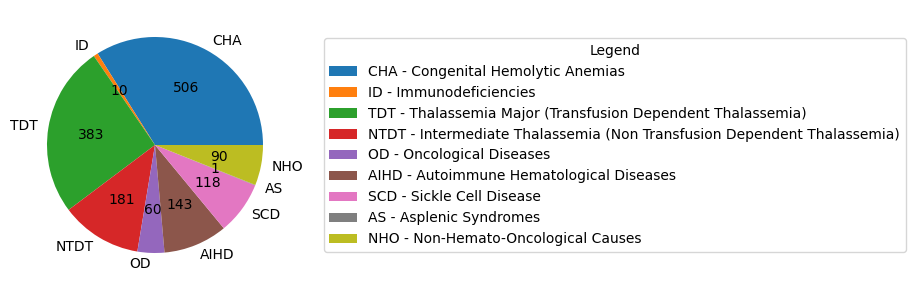

In [25]:
import matplotlib.pyplot as plt

dataset = "INA"
if dataset == "MIMIC":
    labels_short = ["OD", "THA", "SP", "AIHD", "CHA", "SCD"]
    legend_labels = [
        "OD - Oncological Diseases",
        "THA - Thalassemia",
        "SP - Splenectomized",
        "AIHD - Autoimmune Hematological Diseases",
        "CHA - Congenital Hemolytic Anemias",
        "SCD - Sickle Cell Disease",
    ]
    values = [504, 2, 433, 8, 166, 20]
else:
    # INA ditribution
    labels_short = ["CHA", "ID", "TDT", "NTDT", "OD", "AIHD", "SCD", "AS", "NHO"]
    legend_labels = [
        "CHA - Congenital Hemolytic Anemias",
        "ID - Immunodeficiencies",
        "TDT - Thalassemia Major (Transfusion Dependent Thalassemia)",
        "NTDT - Intermediate Thalassemia (Non Transfusion Dependent Thalassemia)",
        "OD - Oncological Diseases",
        "AIHD - Autoimmune Hematological Diseases",
        "SCD - Sickle Cell Disease",
        "AS - Asplenic Syndromes",                                      
        "NHO - Non-Hemato-Oncological Causes",
    ]
    values = [506, 10, 383, 181, 60, 143, 118, 1, 90]


# 👉 funzione per mostrare valori assoluti
def absolute_autopct(vals):
    def inner(pct):
        total = sum(vals)
        val = int(round(pct * total / 100.0))
        return f"{val}"
    return inner

fig, ax = plt.subplots(figsize=(10, 3))

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels_short,
    autopct=absolute_autopct(values)
)
#ax.set_title("Distribution by Disease")

# 👉 legenda separata
ax.legend(
    wedges,
    legend_labels,
    title="Legend",
    loc="center left",
    bbox_to_anchor=(1.1, 0.5)
)

plt.tight_layout()
plt.show()

In [26]:
patients['base_pathology'].value_counts()

base_pathology
OD - Oncological Diseases                   504
SP - Splenecomized                          433
CHA - Congenital Hemolytic Anemias          166
SCD - Sicke Cell Disease                     20
AIHD - Autoimmune Hematological Diseases      8
THA - Thalassemia                             2
Name: count, dtype: int64

In [27]:
patients['age_group'] = patients['anchor_age'].apply(lambda x: "young" if x < 35 else "mature" if x < 55 else "elder" if x < 75 else "geriatric")
#patients['age_group'] = patients['anchor_age'].apply(lambda x: "pediatric" if x <= 12 else "adolescent" if x < 18 else "adult")
counts = patients.groupby(['age_group', 'gender']).size().unstack(fill_value=0)
print(counts.to_latex())

\begin{tabular}{lrr}
\toprule
gender & F & M \\
age_group &  &  \\
\midrule
elder & 239 & 229 \\
geriatric & 77 & 75 \\
mature & 153 & 162 \\
young & 92 & 106 \\
\bottomrule
\end{tabular}



In [28]:
admissions['admission_location'].value_counts()

admission_location
EMERGENCY ROOM                            2404
PHYSICIAN REFERRAL                        1815
WALK-IN/SELF REFERRAL                      531
TRANSFER FROM HOSPITAL                     485
CLINIC REFERRAL                            259
PROCEDURE SITE                             104
TRANSFER FROM SKILLED NURSING FACILITY      59
PACU                                        43
INTERNAL TRANSFER TO OR FROM PSYCH           8
INFORMATION NOT AVAILABLE                    5
AMBULATORY SURGERY TRANSFER                  2
Name: count, dtype: int64

In [29]:
diagnoses = diagnoses.merge(
    d_icd_diag[["icd_code", "long_title"]],
    on="icd_code",
    how="left"
)
diag_join = diagnoses.merge(
    admissions[["hadm_id", "admittime", "subject_id"]],
    on="hadm_id",
    how="left",
    suffixes=('', '_remove')
)
diag_join["event_date"] = pd.to_datetime(diag_join["admittime"]).dt.date

procedures = procedures.merge(
    d_icd_proc[["icd_code", "long_title"]],
    on="icd_code",
    how="left"
)
proc_join = procedures.merge(
    admissions[["hadm_id", "admittime", "subject_id"]],
    on="hadm_id",
    how="left",
    suffixes=('', '_remove')
)
proc_join["event_date"] = pd.to_datetime(proc_join["admittime"]).dt.date

presc_join = prescriptions.merge(
    admissions[["hadm_id", "admittime", "subject_id"]],
    on="hadm_id",
    how="left",
    suffixes=('', '_remove')
)

presc_join["event_date"] = presc_join["starttime"].fillna(
    presc_join["admittime"]
)
presc_join["event_date"] = pd.to_datetime(presc_join["event_date"]).dt.date

#labs_join = labs.merge(
#    d_labitems[["itemid", "label"]],
#    on="itemid",
#    how="left"
#)
#labs_join["date"] = pd.to_datetime(labs_join["charttime"]).dt.date

## Compute events
Per i farmaci, uso STARTTIME se disponibile, sennò la ADMITTIME:

In [30]:

diagnosis_events = diag_join[[
    "subject_id", "icd_code", "icd_version", "event_date", "long_title"
]].rename(columns={
    "long_title": "event", "icd_code" : "code"
})
diagnosis_events["type"] = "disease"
diagnosis_events["code_type"] = diagnosis_events['icd_version'].apply(lambda x: f"ICD-{x}")
# procedures
procedure_events = proc_join[[
    "subject_id", "icd_code", "icd_version", "event_date", "long_title"
]].rename(columns={
    "long_title": "event", "icd_code" : "code"
})
procedure_events["type"] = "therapy"
procedure_events["code_type"] = procedure_events['icd_version'].apply(lambda x: f"ICD-{x}")
prescription_events = presc_join[[
    "subject_id", "drug", "event_date", "formulary_drug_cd", "drug_type"
]].rename(columns={
    "drug": "event", "formulary_drug_cd": "code"
})
prescription_events["type"] = "drug"
prescription_events["code_type"] = prescription_events['code'].apply(lambda x: f"PRODUCT-CODE")
#labs_events = labs_join[["subject_id", "label", "date"]].rename(columns={
#    "label": "event"
#})
#labs_events["type"] = "LAB"
#labs_events['long_title'] = labs_events.loc[:, 'event']

all_events = pd.concat([
    diagnosis_events,
    procedure_events,
    prescription_events,
    #labs_events
], ignore_index=True)

# Rimuovi eventi senza data (rari)
all_events = all_events.dropna(subset=["event_date"])

# Converti id paziente in stringa per JSON
all_events["subject_id"] = all_events["subject_id"].astype(str)
all_events["type"].value_counts()
all_events

,subject_id,code,icd_version,event_date,event,type,code_type,drug_type
0,10008924,86509,9.0,2139-08-20,Other injury into spleen without mention of op...,disease,ICD-9,NaN
1,10008924,78959,9.0,2139-08-20,Other ascites,disease,ICD-9,NaN
2,10008924,2761,9.0,2139-08-20,Hyposmolality and/or hyponatremia,disease,ICD-9,NaN
3,10008924,E8889,9.0,2139-08-20,Unspecified fall,disease,ICD-9,NaN
4,10008924,E8889,9.0,2139-08-20,Other specified metabolic disorders,disease,ICD-9,NaN
...,...,...,...,...,...,...,...,...
379337,19989783,PNEU25I,NaN,2126-06-17,PNEUMOcoccal 23-valent polysaccharide vaccine,drug,PRODUCT-CODE,MAIN
379338,19989783,VITD1000,NaN,2126-06-17,Vitamin D,drug,PRODUCT-CODE,MAIN
379339,19989783,ATOR40,NaN,2126-06-17,Atorvastatin,drug,PRODUCT-CODE,MAIN
379340,19989783,FLEETEN,NaN,2126-06-18,Fleet Enema,drug,PRODUCT-CODE,MAIN


## Extract info of patients with multiple admissions

In [31]:
multi_admit = admissions.groupby("subject_id").size().reset_index(name="num_admissions")
multi_admit = multi_admit[multi_admit["num_admissions"] > 1]
admissions_multi = admissions[admissions["subject_id"].isin(multi_admit["subject_id"])]
admissions_multi

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
513,10008924,22988516,2139-08-20 02:27:00,2139-08-22 18:48:00,NaN,URGENT,P73VYI,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,SINGLE,WHITE,NaN,NaN,0
514,10008924,23676183,2139-07-08 21:28:00,2139-07-29 16:30:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE,NaN,NaN,0
515,10008924,27441295,2139-04-13 21:34:00,2139-04-22 14:56:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOME,Other,English,SINGLE,WHITE,2139-04-13 16:14:00,2139-04-14 00:03:00,0
1056,10019003,21457723,2155-07-10 17:48:00,2155-07-18 16:59:00,NaN,EW EMER.,P5069B,TRANSFER FROM HOSPITAL,HOME,Medicare,English,WIDOWED,WHITE,2155-07-10 12:46:00,2155-07-10 19:03:00,0
1057,10019003,25508812,2155-05-22 21:46:00,2155-05-30 03:30:00,NaN,OBSERVATION ADMIT,P36S63,PHYSICIAN REFERRAL,HOME,Medicare,English,WIDOWED,WHITE,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545424,19989783,23110090,2130-03-15 22:37:00,2130-03-26 16:30:00,NaN,OBSERVATION ADMIT,P2915M,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2130-03-15 13:24:00,2130-03-16 00:01:00,0
545425,19989783,24282820,2130-08-02 17:27:00,2130-08-07 13:46:00,NaN,EW EMER.,P07KMB,WALK-IN/SELF REFERRAL,CHRONIC/LONG TERM ACUTE CARE,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2130-08-02 12:52:00,2130-08-02 18:31:00,0
545426,19989783,25490687,2126-08-11 00:00:00,2126-08-28 12:53:00,NaN,DIRECT EMER.,P32VJE,PHYSICIAN REFERRAL,HOME HEALTH CARE,Private,English,SINGLE,BLACK/AFRICAN AMERICAN,NaN,NaN,0
545427,19989783,26984195,2130-07-12 08:34:00,2130-08-01 15:50:00,NaN,OBSERVATION ADMIT,P42XKM,PHYSICIAN REFERRAL,CHRONIC/LONG TERM ACUTE CARE,Medicare,English,SINGLE,BLACK/AFRICAN AMERICAN,2130-07-12 06:35:00,2130-07-12 09:01:00,0


## Concat all together

In [32]:
from collections import defaultdict
import json

patient_dict = defaultdict(list)

for _, row in tqdm(all_events.iterrows(), total=len(all_events), desc='Processing Events'):
    subj_id = row["subject_id"]
    event_entry = {
        "type": row["type"],
        "event": str(row["event"]),
        "date": str(row["event_date"]),
        "code": str(row["code"]),
        "code_type": str(row["code_type"]),
        "code_descr": str(row["event"])
    }
    patient_dict[subj_id].append(event_entry)


for subj_id, events in tqdm(patient_dict.items(), total=len(patient_dict), desc='Events to Patients'):
    events_sorted = sorted(
        events,
        key=lambda e: e["date"]
    )
    patient_dict[subj_id] = events_sorted

Processing Events:   0%|          | 0/379342 [00:00<?, ?it/s]

Events to Patients:   0%|          | 0/1133 [00:00<?, ?it/s]

## Determina esito dell’ultimo ricovero 
Per ciascun paziente:

+ Trova l’ultima admittime in ADMISSIONS

+ Prendi hospital_expire_flag di quell’admission

In [33]:
admissions["admittime"] = pd.to_datetime(admissions["admittime"])

# Trova ultima admission per paziente
last_adm = admissions.sort_values("admittime").groupby("subject_id").tail(1)

# Keep only subject_id and expire flag
last_adm = last_adm[["subject_id", "hospital_expire_flag"]]

# Convert subject_id a string (come nel tuo patient_dict)
last_adm["subject_id"] = last_adm["subject_id"].astype(str)
last_adm

,subject_id,hospital_expire_flag
146808,12708660,0
404939,17420450,0
428212,17846441,0
222686,14098423,0
285364,15242781,0
...,...,...
476835,18724560,0
242545,14454179,1
229627,14226649,0
200443,13686614,0


## Stampa cause di morte

In [34]:

admissions["admittime"] = pd.to_datetime(admissions["admittime"])

# Ultimo ricovero per paziente
last_adm = admissions.sort_values("admittime").groupby("subject_id").last().reset_index()

# Pazienti morti in ospedale
dead = last_adm[last_adm["hospital_expire_flag"] == 1]

# Join con diagnosi
dead_diag = dead.merge(diagnoses, on=["subject_id", "hadm_id"])

# Diagnosi principale
cause_of_death = dead_diag[dead_diag["seq_num"] == 1]

# 🔴 JOIN CON DESCRIZIONE ICD
cause_of_death = cause_of_death.merge(
    d_icd_diag,
    on=["icd_code", "icd_version"],
    how="left"
)

# Output finale
#print(
cause_of_death[[
    "subject_id",
    "hadm_id",
    "icd_code",
    "long_title_x",   # 👈 descrizione testuale
]]#.head()

,subject_id,hadm_id,icd_code,long_title_x
0,10053082,24211160,431,Intracerebral hemorrhage
1,10056037,21758160,80331,Other closed skull fracture with other and uns...
2,10065641,21342203,S36032A,"Major laceration of spleen, initial encounter"
3,10098993,20518100,41402,Coronary atherosclerosis of autologous vein by...
4,10228499,24780517,I6201,Nontraumatic acute subdural hemorrhage
...,...,...,...,...
99,19696160,21376742,28959,Other diseases of spleen
100,19740018,29882123,T82310A,Breakdown (mechanical) of aortic (bifurcation)...
101,19747328,29300235,0389,Unspecified septicemia
102,19817448,20940988,03810,"Staphylococcal septicemia, unspecified"


In [35]:
diagnoses[diagnoses['long_title'].str.contains('Thalassemia', case=False)]

,subject_id,hadm_id,seq_num,icd_code,icd_version,long_title
697,10082640,20566971,1,D561,10,Beta thalassemia
701,10082640,22930426,1,D561,10,Beta thalassemia
709,10082640,23298774,3,D561,10,Beta thalassemia
1660,10228499,24780517,7,D5740,10,Sickle-cell thalassemia without crisis
1666,10228499,26251808,2,D560,10,Alpha thalassemia
...,...,...,...,...,...,...
70512,18917761,27256385,6,D561,10,Beta thalassemia
70599,18917761,28956569,7,28244,9,Beta thalassemia
70674,18917761,29428069,6,28244,9,Beta thalassemia
70694,18917761,29519853,11,D563,10,Thalassemia minor


## Prendi genere e altre info da PATIENTS
+ Merge informazioni statiche

In [36]:
#patients["subject_id"] = patients["subject_id"].astype(str)

# Seleziona colonne utili
patients_info = patients[["subject_id", "gender", "age_group", "base_pathology"]]
patient_static = patients_info.merge(
    last_adm,
    on="subject_id",
    how="left"
)
patient_static

,subject_id,gender,age_group,base_pathology,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10008924,F,mature,OD - Oncological Diseases,22988516,2139-08-20 02:27:00,2139-08-22 18:48:00,None,URGENT,P73VYI,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,SINGLE,WHITE,2139-04-13 16:14:00,2139-04-14 00:03:00,0
1,10015701,F,geriatric,OD - Oncological Diseases,25619291,2133-08-01 17:25:00,2133-08-04 21:42:00,None,EU OBSERVATION,P416B5,EMERGENCY ROOM,None,Medicare,Persian,DIVORCED,OTHER,2133-08-01 14:43:00,2133-08-01 19:14:00,0
2,10019003,F,elder,OD - Oncological Diseases,26226543,2155-10-17 18:01:00,2155-11-03 18:00:00,None,ELECTIVE,P18L3B,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicare,English,WIDOWED,WHITE,2155-07-10 12:46:00,2155-07-10 19:03:00,0
3,10029776,F,geriatric,CHA - Congenital Hemolytic Anemias,22438503,2131-08-03 16:50:00,2131-08-07 15:15:00,None,EW EMER.,P05QSS,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,MARRIED,OTHER,2131-08-03 11:57:00,2131-08-03 17:57:00,0
4,10031816,M,mature,SP - Splenecomized,22448068,2200-05-27 18:36:00,2200-05-28 15:30:00,None,EU OBSERVATION,P978VC,EMERGENCY ROOM,HOME,Private,Chinese,MARRIED,ASIAN,2200-05-27 12:04:00,2200-05-27 20:28:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128,19978766,M,mature,SP - Splenecomized,23289238,2165-04-02 07:15:00,2165-04-07 16:00:00,None,SURGICAL SAME DAY ADMISSION,P59T02,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,English,WIDOWED,OTHER,2165-03-26 12:04:00,2165-03-26 20:30:00,0
1129,19984573,M,young,OD - Oncological Diseases,29579818,2113-02-14 01:55:00,2113-02-16 15:00:00,None,EW EMER.,P34T9T,EMERGENCY ROOM,HOME,Private,English,SINGLE,WHITE,2113-02-14 00:37:00,2113-02-14 03:41:00,0
1130,19984781,F,geriatric,CHA - Congenital Hemolytic Anemias,28904296,2165-09-14 22:13:00,2165-09-27 14:20:00,None,OBSERVATION ADMIT,P913PP,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,Medicare,English,DIVORCED,WHITE,2165-09-14 11:42:00,2165-09-14 23:49:00,0
1131,19988786,F,geriatric,SP - Splenecomized,21886944,2184-06-11 03:23:00,2184-06-17 15:57:00,None,OBSERVATION ADMIT,P3715A,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,Russian,MARRIED,WHITE - RUSSIAN,2184-06-10 23:31:00,2184-06-11 17:59:00,0


In [37]:
patient_static['hospital_expire_flag'].value_counts(dropna=False)

hospital_expire_flag
0    1029
1     104
Name: count, dtype: int64

In [38]:

counts = patient_static.groupby(['age_group', 'gender']).agg(
    total=('hospital_expire_flag', 'size'),          # totale pazienti
    dead=('hospital_expire_flag', 'sum')             # numero deceduti (assumendo 1=dead, 0=alive)
).unstack(fill_value=0)

print(counts.to_latex())

\begin{tabular}{lrrrr}
\toprule
 & \multicolumn{2}{r}{total} & \multicolumn{2}{r}{dead} \\
gender & F & M & F & M \\
age_group &  &  &  &  \\
\midrule
elder & 239 & 229 & 24 & 26 \\
geriatric & 77 & 75 & 5 & 17 \\
mature & 153 & 162 & 11 & 15 \\
young & 92 & 106 & 0 & 6 \\
\bottomrule
\end{tabular}



## Salva JSON file

In [40]:
final_data = []

for subj_id, events in tqdm(patient_dict.items(), total=len(patient_dict), desc='Patients'):
    
    # Cerca info statiche
    info = patient_static[patient_static["subject_id"] == int(subj_id)]
    
    if not info.empty:
        gender = info.iloc[0]["gender"]
        age_group = info.iloc[0]["age_group"]
        expire_flag = info.iloc[0]["hospital_expire_flag"]
        primary_disease = info.iloc[0]["base_pathology"]
    else:
        gender = None
        age_group = None
        expire_flag = None
        primary_disease = None
    
    patient_entry = {
        "id": subj_id,
        "gender": gender,
        "age_group": age_group,
        "base_pathology_area": primary_disease,
        "is_dead?": int(expire_flag) if pd.notnull(expire_flag) else None,
        "events": events
    }
    
    final_data.append(patient_entry)
import json

with open(f"mimic-iv_asplenic_{len(selected_idxs)}.json", "w") as f:
    json.dump(final_data, f, indent=2)


Patients:   0%|          | 0/1133 [00:00<?, ?it/s]

In [102]:
print(spleen_codes.to_latex(index=False))

\begin{tabular}{lrl}
\toprule
icd_code & icd_version & long_title \\
\midrule
1537 & 9 & Malignant neoplasm of splenic flexure \\
2894 & 9 & Hypersplenism \\
28951 & 9 & Chronic congestive splenomegaly \\
28953 & 9 & Neutropenic splenomegaly \\
44283 & 9 & Aneurysm of splenic artery \\
90223 & 9 & Injury to splenic artery \\
90234 & 9 & Injury to splenic vein \\
90239 & 9 & Injury to portal and splenic veins, other \\
C185 & 10 & Malignant neoplasm of splenic flexure \\
C861 & 10 & Hepatosplenic T-cell lymphoma \\
D5702 & 10 & Hb-SS disease with splenic sequestration \\
D57212 & 10 & Sickle-cell/Hb-C disease with splenic sequestration \\
D57412 & 10 & Sickle-cell thalassemia, unspecified, with splenic sequestration \\
D57432 & 10 & Sickle-cell thalassemia beta zero with splenic sequestration \\
D57452 & 10 & Sickle-cell thalassemia beta plus with splenic sequestration \\
D57812 & 10 & Other sickle-cell disorders with splenic sequestration \\
D730 & 10 & Hyposplenism \\
D731 & 10 & Hype